In [4]:
import numpy as np 
import pandas as pd 
import h5py
import re
import uproot
import glob 
import copy, sys, os
import matplotlib.pyplot as plt
from tqdm import tqdm 
# adding path to folder
sys.path.insert(0, '../tools/')
from utils import ParticleCode, load_dataset
from caf_readers import CafReader
from mx2_matching import Mx2_DS_Match
# Load your custom style 
plt.style.use('./cfg/my_custom_plot.mplstyle')

# use these lines on top of your matplotlib script
import matplotlib.ticker
class MyLocator(matplotlib.ticker.AutoMinorLocator):
    def __init__(self, n=4):
        super().__init__(n=n)
matplotlib.ticker.AutoMinorLocator = MyLocator        
 
# Now use matplotlib as usual.       
import matplotlib.pyplot as plt
plt.rcParams["xtick.minor.visible"] =  True
plt.rcParams["ytick.minor.visible"] =  True

In [5]:
def check_FDV(in_vect):
    tpc_wall_dist = 8.0
    xb = 63.931
    yb = 62.076
    zb = 64.3163
    x = in_vect[0]
    y = in_vect[1]
    z = in_vect[2]
    is_fiducial = False
    if(
        (tpc_wall_dist < np.abs(x) < xb - tpc_wall_dist) and
        (tpc_wall_dist < np.abs(y) < yb - tpc_wall_dist) and
        (tpc_wall_dist < np.abs(z) < zb - tpc_wall_dist)):
        is_fiducial=True
    return is_fiducial

In [6]:
# Load datasets 
n_files = 0
location = "nersc"
df = load_dataset(n_files,location)
# Create a caf reader
caf_reader = CafReader(df)
particle_tab = ParticleCode()

Openning MiniRun 5 beta 2.a CAFs
Reading  0  files


0it [00:00, ?it/s]

1it [00:00,  1.30it/s]


In [7]:
print(f"Number of events {len(df)}")
n_events = len(df)

Number of events 199


In [8]:
# Print FV events
for ev in range(n_events):
    # Get event
    ixn = df.iloc[ev]
    # Number of neutrinos
    nnu = ixn['rec.mc.nnu']

    true_numucc = False 
    if(nnu==0):
        continue
    else:
        for i_nu in range(nnu):
            temp_dict = caf_reader.get_true_ixn_data(ixn,i_nu)
            temp_vtx=[
                temp_dict['rec.mc.nu.vtx.x'],
                temp_dict['rec.mc.nu.vtx.y'],
                temp_dict['rec.mc.nu.vtx.z']
            ]

            # check if FDV
            is_fiducial = check_FDV(temp_vtx)
            primary_muon = False
            if(particle_tab.muon in  np.abs(temp_dict['rec.mc.nu.prim.pdg'])):
                primary_muon = True
            if(is_fiducial and primary_muon):
                print(f"True fiducial nu-mu, event {ev}, ixn {i_nu}")
                true_numucc = True

    if(true_numucc):
        # Now we repeat for reco vertices
        nreco_nu = ixn["rec.common.ixn.dlp..length"]
        if(nreco_nu==0):
            print("----------------------------------------")
            continue
        else:
            for i_nu in range(nreco_nu):
                temp_dict = caf_reader.get_reco_ixn_data(ixn,i_nu)
                temp_vtx=[
                    temp_dict['rec.common.ixn.dlp.vtx.x'],
                    temp_dict['rec.common.ixn.dlp.vtx.y'],
                    temp_dict['rec.common.ixn.dlp.vtx.z']
                ]
                is_fiducial = check_FDV(temp_vtx)
                if(is_fiducial):
                    print(f"Reco nu, event {ev}, reco ixn {i_nu}")
                    print("----------------------------------------")
                




        

True fiducial nu-mu, event 35, ixn 1


TypeError: 'NoneType' object is not subscriptable

In [ ]:
my_event = 35
my_ixn = 1

In [ ]:
caf_reader.dump_branches(df.iloc[my_event],"reco")

Printing reco info...
rec.common.ixn.dlp.id [0 1 2]
rec.common.ixn.dlp.part.dlp..length [3 4 1]
rec.common.ixn.dlp.part.dlp..totarraysize 8
rec.common.ixn.dlp.part.dlp.E [ 0.00410782  0.01031766  0.336059    0.18058206  0.23415914  0.09725311
  0.11639781 -0.001     ]
rec.common.ixn.dlp.part.dlp.E_method [3 3 2 3 2 1 1 2]
rec.common.ixn.dlp.part.dlp.contained [1 1 0 0 0 1 1 0]
rec.common.ixn.dlp.part.dlp.end.x [    -inf     -inf  18.8445     -inf  48.1089  51.2127  47.2221 -30.3729]
rec.common.ixn.dlp.part.dlp.end.y [   -inf    -inf 49.4391    -inf 16.1841  9.9765 16.1841 61.8543]
rec.common.ixn.dlp.part.dlp.end.z [    -inf     -inf  64.5147     -inf -23.7219 -18.8445 -21.9483  60.9675]
rec.common.ixn.dlp.part.dlp.p.x [ 0.          0.00168523 -0.00295292  0.09945437  0.10515177  0.2306172
  0.20627174  0.        ]
rec.common.ixn.dlp.part.dlp.p.y [ 0.00205331 -0.00264821 -0.01641331 -0.01937243 -0.02084188 -0.3146811
  0.20204496  0.        ]
rec.common.ixn.dlp.part.dlp.p.z [ 0.00410664

In [ ]:
truth_data = caf_reader.get_true_ixn_data(df.iloc[my_event],my_ixn,True)

Extracting true data for ixn 1
Number of primary particles 23
Number of pre-prim 16
Number of secondary particles 3
Number of pre-sec 0


In [ ]:
print(truth_data['rec.mc.nu.prim.pdg'])
print(truth_data['rec.mc.nu.prim.start_pos.x'])
print(truth_data['rec.mc.nu.prim.start_pos.y'])
print(truth_data['rec.mc.nu.prim.start_pos.z'])

print(truth_data['rec.mc.nu.prim.end_pos.x'])
print(truth_data['rec.mc.nu.prim.end_pos.y'])
print(truth_data['rec.mc.nu.prim.end_pos.z'])


[ -13 2212 2212 2112 2112 2112 2212 2212 2112 2112 2212 2212 2112 2112
 2212 2212 2112 2112 2212 2212 2112 2112  111]
[47.933544 47.933544 47.933544 47.933544 47.933544 47.933544 47.933544
 47.933544 47.933544 47.933544 47.933544 47.933544 47.933544 47.933544
 47.933544 47.933544 47.933544 47.933544 47.933544 47.933544 47.933544
 47.933544 47.933544]
[16.447887 16.447887 16.447887 16.447887 16.447887 16.447887 16.447887
 16.447887 16.447887 16.447887 16.447887 16.447887 16.447887 16.447887
 16.447887 16.447887 16.447887 16.447887 16.447887 16.447887 16.447887
 16.447887 16.447887]
[-22.971384 -22.971384 -22.971384 -22.971384 -22.971384 -22.971384
 -22.971384 -22.971384 -22.971384 -22.971384 -22.971384 -22.971384
 -22.971384 -22.971384 -22.971384 -22.971384 -22.971384 -22.971384
 -22.971384 -22.971384 -22.971384 -22.971384 -22.971384]
[-449.92056     45.95327     47.93572     54.46301     48.516388
   39.616722    44.314106    48.28016      9.635338    45.985874
   51.075333    47.89702

In [ ]:
true_muon_index = 0
mu_sz = truth_data['rec.mc.nu.prim.start_pos.z'][true_muon_index]
mu_sx = truth_data['rec.mc.nu.prim.start_pos.x'][true_muon_index]
mu_ez = truth_data['rec.mc.nu.prim.end_pos.z'][true_muon_index]
mu_ex = truth_data['rec.mc.nu.prim.end_pos.x'][true_muon_index]

In [ ]:
my_reco_ixn = 1
reco_part_index = 1
reco_data = caf_reader.get_reco_ixn_data(df.iloc[my_event],my_reco_ixn,True)
reco_sz = reco_data['rec.common.ixn.dlp.part.dlp.start.z'][reco_part_index]
reco_sy = reco_data['rec.common.ixn.dlp.part.dlp.start.y'][reco_part_index]
reco_sx = reco_data['rec.common.ixn.dlp.part.dlp.start.x'][reco_part_index]
reco_ez = reco_data['rec.common.ixn.dlp.part.dlp.end.z'][reco_part_index]
reco_ey = reco_data['rec.common.ixn.dlp.part.dlp.end.y'][reco_part_index]
reco_ex = reco_data['rec.common.ixn.dlp.part.dlp.end.x'][reco_part_index]

Number of reconstructed particles 4
PDG codes of reco parts [  22  211 2212 2212]
start points [-14.4105  64.5147 -22.3917 -13.9671], [52.5429 19.2879 47.6655 44.1183]
end points [    -inf -23.7219 -18.8445 -21.9483], [   -inf 48.1089 51.2127 47.2221]


In [ ]:
# Lets check MINERvA stuff
minerva_data = caf_reader.get_minerva_data(df.iloc[my_event])
print(f"Number of MINERvA tracks {np.sum(minerva_data['rec.nd.minerva.ixn.tracks..length'])}")
print(f"Reco tracks sz {minerva_data['rec.nd.minerva.ixn.tracks.start.z']}")
print(f"Reco tracks sx {minerva_data['rec.nd.minerva.ixn.tracks.start.x']}")
#print(f"Number of reco tracks {reco_data['rec.nd.minerva.ixn.tracks..length']}")

Number of MINERvA tracks 5
Reco tracks sz [ 166.4198  168.4678  249.1857 -237.4402  166.4198]
Reco tracks sx [-77.360176 -25.555271 -71.150444  21.752794 -14.902894]


In [ ]:
# Test the case when dz > 0 
test_muon_track = [[reco_sx,reco_sy,reco_ez],[reco_ex,reco_ey,reco_sz]]
Mx2_DS_Match(test_muon_track,minerva_data)

2x2 track length 93.00 cm


(None, 0, None, None, True)

In [ ]:
test_muon_track = [[reco_sx,reco_sy,reco_sz],[reco_ex,reco_ey,reco_ez]]
bm, overlap, dx, dy, exit_minerva = Mx2_DS_Match(test_muon_track,minerva_data)
print(bm,overlap,dx,dy,exit_minerva)

2x2 track length 93.00 cm
Flipping track direction
Original start [19.2879, 21.9483, 64.5147]
Original end [48.1089, 16.1841, -23.7219]
New start [48.1089, 16.1841, -23.7219]
New end [19.2879, 21.9483, 64.5147]
4 0.80010366 0.90521526 -0.77220535 True


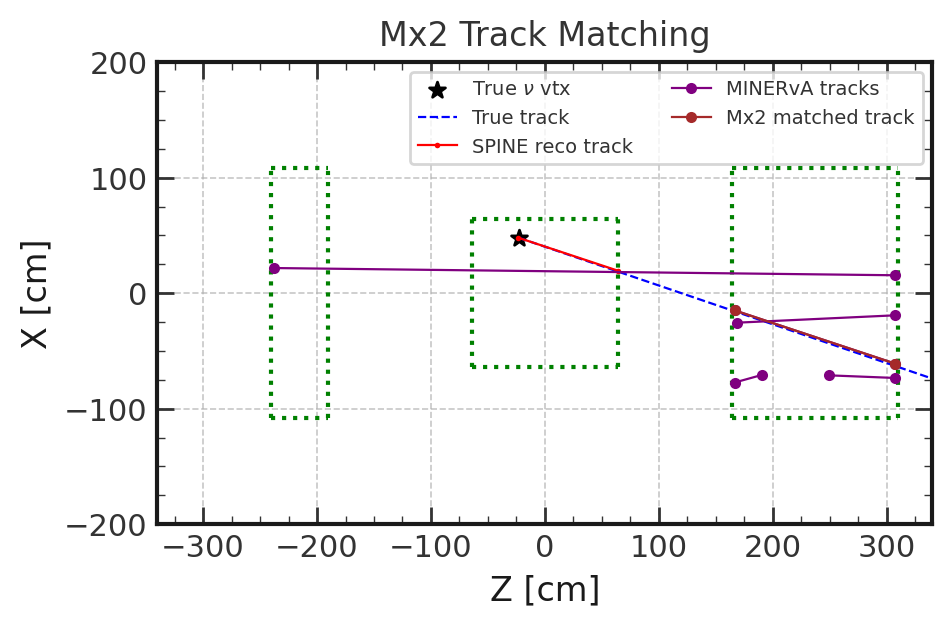

In [ ]:
# Draw 2x2 boundaries
plt.plot([-64.3163,64.3163], [63.931,63.931], color='g', linestyle='dotted')
plt.plot([-64.3163,64.3163], [-63.931,-63.931], color='g', linestyle='dotted')
plt.plot([-64.3163,-64.3163], [-63.931,63.931], color='g', linestyle='dotted')
plt.plot([64.3163,64.3163], [-63.931,63.931], color='g', linestyle='dotted')

# Draw MINERvA US boundaries

# Draw MINERvA boundaries
x_low =-108.0
x_up = 108.0
z_ds_low = 164.0
z_ds_up = 310.0
z_us_low = -240.0
z_us_up = -190.0

# DS
plt.plot([z_ds_low,z_ds_up],[x_low,x_low],color='g', linestyle='dotted')
plt.plot([z_ds_low,z_ds_up],[x_up,x_up],color='g', linestyle='dotted')
plt.plot([z_ds_low,z_ds_low],[x_low,x_up],color='g', linestyle='dotted')
plt.plot([z_ds_up,z_ds_up],[x_low,x_up],color='g', linestyle='dotted')

# US
plt.plot([z_us_low,z_us_up],[x_low,x_low],color='g', linestyle='dotted')
plt.plot([z_us_low,z_us_up],[x_up,x_up],color='g', linestyle='dotted')
plt.plot([z_us_low,z_us_low],[x_low,x_up],color='g', linestyle='dotted')
plt.plot([z_us_up,z_us_up],[x_low,x_up],color='g', linestyle='dotted')

# Draw points
plt.scatter(truth_data['rec.mc.nu.vtx.z'],truth_data['rec.mc.nu.vtx.x'],marker="*",color='black',label=r"True $\nu$ vtx")
plt.plot([mu_sz,mu_ez],[mu_sx,mu_ex],marker="^",markersize=0.8,color='blue',lw=0.8,ls="--",label="True track")
plt.plot([reco_sz,reco_ez],[reco_sx,reco_ex],marker="o",markersize=2.0,color='red',lw=0.8,ls="-",label="SPINE reco track")
plt.plot


# Draw MINERvA tracks
n_minerva_tracks = np.sum(minerva_data['rec.nd.minerva.ixn.tracks..length'])

for itrack in range(n_minerva_tracks):
    sz=minerva_data['rec.nd.minerva.ixn.tracks.start.z'][itrack]
    sx=minerva_data['rec.nd.minerva.ixn.tracks.start.x'][itrack]
    ez=minerva_data['rec.nd.minerva.ixn.tracks.end.z'][itrack]
    ex=minerva_data['rec.nd.minerva.ixn.tracks.end.x'][itrack]


    if(itrack==0):
        plt.plot([sz,ez],[sx,ex], marker="o",markersize=4.0,color='purple',lw=0.8,ls="-",label='MINERvA tracks')
    else:
        plt.plot([sz,ez],[sx,ex], marker="o",markersize=4.0,color='purple',lw=0.8,ls="-")

    if(itrack==bm):
        plt.plot([sz,ez],[sx,ex], marker="o",markersize=4.0,color='brown',lw=0.8,ls="-",label='Mx2 matched track')



plt.title("Mx2 Track Matching")
plt.xlabel("Z [cm]")
plt.ylabel("X [cm]")
plt.xlim(-340,340)
plt.ylim(-200,200)
plt.legend(fontsize=7,ncol=2)
#plt.savefig("./plots/mx2_track_matching_muon_wrong_pion_2.png",bbox_inches="tight")
#plt.savefig("./plots/mx2_track_matching_muon_wrong_pion_2.pdf",bbox_inches="tight")
plt.show()